In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

In [3]:
# convert the dataset into Pandas DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df['species'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor',
2: 'virginica'})

In [4]:
# Split the dataset into features and target
X = iris.data
y = iris.target

In [5]:
# Convert the labels to categorical (one-hot encoding)
y = to_categorical(y, num_classes=3)

In [6]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)

In [7]:
# Initialize a Sequential model
model = Sequential()

In [8]:
# Add layers to the model
model.add(Dense(10, input_dim=4, activation='relu')) # Input layer with 4 features, first hidden layer with 10 neurons
model.add(Dense(10, activation='relu')) # Second hidden layer with 10 neurons
model.add(Dense(3, activation='softmax')) # Output layer with 3 neurons (for 3 classes) and softmax activation

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam',
metrics=['accuracy'])

In [10]:
# Train the model and capture the training history
history = model.fit(X_train, y_train, epochs=100, batch_size=10,
validation_data=(X_test, y_test), verbose=1)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.0538 - loss: 1.1185 - val_accuracy: 0.2000 - val_loss: 1.0783
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2791 - loss: 1.0397 - val_accuracy: 0.2444 - val_loss: 0.9861
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3373 - loss: 0.9571 - val_accuracy: 0.6222 - val_loss: 0.9014
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6534 - loss: 0.8914 - val_accuracy: 0.7556 - val_loss: 0.8220
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7920 - loss: 0.8237 - val_accuracy: 0.8444 - val_loss: 0.7459
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8747 - loss: 0.7777 - val_accuracy: 0.8889 - val_loss: 0.6828
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8608 - loss: 0.7021 - val_accuracy: 0.8889 - val_loss: 0.6254
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8856 - loss: 0.6384 - val_accuracy: 0.

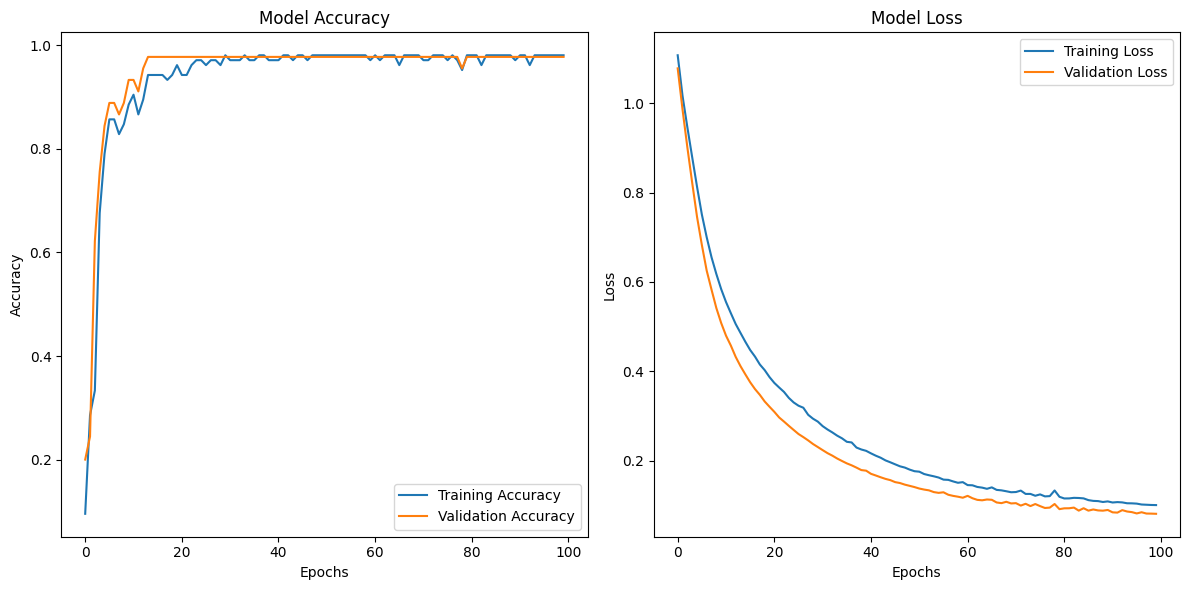

In [11]:
import matplotlib.pyplot as plt

# Plot accuracy curve
plt.figure(figsize=(12, 6))
# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Plot loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Evaluate the model on the test set
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [13]:
# Convert predictions from one-hot to label encoding
y_pred_labels = y_pred.argmax(axis=1)
y_true_labels = y_test.argmax(axis=1)

In [14]:
# Evaluate accuracy and print classification report
print("Accuracy:", accuracy_score(y_true_labels, y_pred_labels))
print("Classification Report:\n", classification_report(y_true_labels,
y_pred_labels))

Accuracy: 0.9777777777777777
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

